In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '250',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 8}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.357274, valid=0.028444, test=0.028269
	validation loss decreased (inf -> 0.028444), saving model ...
	epoch 2 losses: train=0.316317, valid=0.033012, test=0.032121
	early stopping counter: 1 out of 10
	epoch 3 losses: train=0.164511, valid=0.020843, test=0.019906
	validation loss decreased (0.028444 -> 0.020843), saving model ...
	epoch 4 losses: train=0.048356, valid=0.011817, test=0.011090
	validation loss decreased (0.020843 -> 0.011817), saving model ...
	epoch 5 losses: train=0.029859, valid=0.006597, test=0.006429
	validation loss decreased (0.011817 -> 0.006597), saving model ...
	epoch 6 losses: train=0.012557, valid=0.002541, test=0.002544
	validation loss decreased (0.006597 -> 0.002541), saving model ...
	epoch 7 losses: train=0.008413, valid=0.002140, test=0.002059
	validation loss decreased (0.002541 -> 0.002140), saving model ...
	epoch 8 losses: train=0.007020, valid=0.001771, test=0.001739
	validation loss decreased

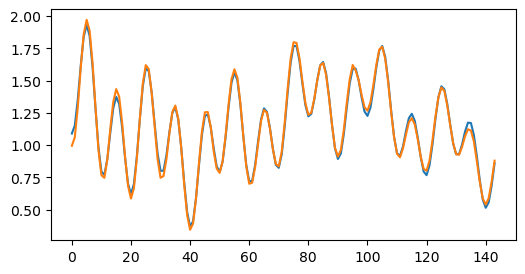

In [7]:
model.eval()
_, _, data_loader = dataset.load_stat()

jdata = 12

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break